# 05 Historical Backtest and Conclusions

**In this notebook** Assemble everything into an event-driven backtest on real
out-of-sample data, then conclude. Three implementations of the *same* OU
signal are compared: a classic share pairs trade, and one option trade marked
two ways (constant-parameter vs regime-switching pricer).

**Design discipline.** Nothing is re-estimated here. Every parameter
$\hat\beta, \hat\alpha, \theta, \sigma_{\text{stat}}$, GBM vols/correlation,
regime model is frozen from the training window of notebook 01
(2021-01 → 2024-07). This notebook re-downloads prices and *reconstructs* the
signal deterministically from those frozen parameters; the resulting trade
table must match notebook 01's exactly. The test window is
2024-07 → 2026-06.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm

TICKERS = ("MO", "PM")
DATA_START, DATA_END = "2021-01-01", "2026-07-01"
TRAIN_END = "2024-07-01"
TRADING_DAYS, r_f = 252, 0.04

BETA, ALPHA = 0.735372, 0.302487
KAPPA, THETA = 6.935348, 0.004386
SIGMA_X, SIGMA_STAT = 0.176370, 0.047356
HALF_LIFE_DAYS = 25.1859
MAX_HOLD, T_OPT = 50, 0.198413
Z_ENTRY, Z_EXIT = 2.0, 0.0

SIGMA1, SIGMA2, RHO = 0.209149, 0.194565, 0.560769
S1_0, S2_0 = 40.0410, 94.0219
H_RATIO = 0.313172

rng = np.random.default_rng(5)
plt.rcParams["figure.figsize"] = (10, 5)

# 6. Historical backtest: the full strategy

**Signal (frozen training parameters — no look-ahead):** standardized OU
spread $z_t = (X_t - \theta)/\sigma_{\text{stat}}$ crosses $\pm 2
\Rightarrow$ enter; $z_t$ reaches $0$, or the max holding period
$2 \times$ half-life $= 50$ trading days elapses, or the data ends
$\Rightarrow$ exit. Each trade records its **exit reason** (target / timeout
/ end-of-data); an end-of-data exit is *censored* and flagged.

**The traded option.** At each entry, set the local dollar hedge ratio
$h = \beta\, S_1^e / S_2^e$ and strike $K = S_1^e - h S_2^e =
(1-\beta)\,S_1^e$ — **at the money in the spread** (notebook 02 §2.2; this is
$K_{\text{ATM}}$, not $K \approx 0$). Maturity $T = T_{\text{opt}} \approx
0.2$y matches the max holding period.

- $z < -2$ (spread too low, expect rise): buy a **call** on $S_1 - hS_2$,
  legs $A = S_1$, $B = hS_2$.
- $z > +2$ (expect fall): buy a **put**, implemented as a call on
  $hS_2 - S_1$ (legs swapped: $A = hS_2$, $B = S_1$; the strike
  $K = A^e - B^e$ is then negative, which is fine — the option is still ATM
  in the spread).

The option is **not delta-hedged** — the directional spread exposure *is*
the trade.

**Control-variate orientation.** The Margrabe $K = 0$ exchange option is the
control for every daily mark, but for swapped (short-spread) trades
$\max(A - B, 0)$ is far out of the money and nearly worthless as a control.
The markers therefore use the **in-the-money exchange direction** —
$\max(A-B, 0)$ when $A^e > B^e$, $\max(B-A, 0)$ otherwise (both Margrabe
closed forms; the CV regression handles the sign automatically).

**Sizing for comparability.** The share trade holds
$\Delta^e \cdot (1, -h)$ shares per option, where $\Delta^e$ is the option's
entry delta computed by a finite-difference bump **on the marker itself**
(common random numbers make the quotient smooth). Using Margrabe $K=0$
deltas here would be wrong for this pair: they are pinned near $1$ while the
ATM option's delta is near $0.5$, which would double-size the share leg.

**Marking.** Exchange-listed spread options on single-stock pairs do not
trade, so positions are model-marked daily: constant-parameter pricer
(`BSMarker`) vs regime-switching pricer (`RSMarker`) conditioned on the
regime detected from trailing realized vol on the *real* price path. Early
exits realize model value; timeout and end-of-data exits realize the actual
payoff. Model-marked P&L is realistic for OTC books but is this backtest's
main limitation. No transaction costs.


In [3]:
# From notebooks 01–04 
def _margrabe_d1_d2(S1, S2, sigma1, sigma2, rho, T):
    sig_hat = np.sqrt(sigma1**2 - 2*rho*sigma1*sigma2 + sigma2**2)
    sqT = sig_hat * np.sqrt(T)
    d1 = (np.log(S1 / S2) + 0.5 * sig_hat**2 * T) / sqT
    return d1, d1 - sqT


def margrabe_price(S1, S2, sigma1, sigma2, rho, T):
    d1, d2 = _margrabe_d1_d2(S1, S2, sigma1, sigma2, rho, T)
    return S1 * norm.cdf(d1) - S2 * norm.cdf(d2)


def margrabe_price_sighat(S1, S2, sig_hat, T):
    sqT = sig_hat * np.sqrt(T)
    d1 = (np.log(S1 / S2) + 0.5 * sig_hat**2 * T) / sqT
    return S1 * norm.cdf(d1) - S2 * norm.cdf(d1 - sqT)


def label_regimes(returns: pd.DataFrame, window=21, q=0.75) -> pd.Series:
    rv = returns.iloc[:, 0].rolling(window).std() * np.sqrt(TRADING_DAYS)
    rv = rv.dropna()
    labels = (rv > rv.quantile(q)).astype(int)
    labels.name = "regime"
    return labels


def estimate_regime_params(returns: pd.DataFrame, labels: pd.Series):
    ret = returns.loc[labels.index]
    y = labels.values
    P = np.zeros((2, 2))
    for i in range(2):
        for j in range(2):
            P[i, j] = np.sum((y[:-1] == i) & (y[1:] == j))
    P = P / P.sum(axis=1, keepdims=True)
    sigma1, sigma2, rho = np.zeros(2), np.zeros(2), np.zeros(2)
    counts = np.zeros(2, dtype=int)
    for k in range(2):
        rk = ret[y == k]
        counts[k] = len(rk)
        sigma1[k] = rk.iloc[:, 0].std(ddof=1) * np.sqrt(TRADING_DAYS)
        sigma2[k] = rk.iloc[:, 1].std(ddof=1) * np.sqrt(TRADING_DAYS)
        rho[k] = rk.iloc[:, 0].corr(rk.iloc[:, 1])
    pi1 = (1 - P[0, 0]) / (2 - P[0, 0] - P[1, 1])
    return dict(P=P, sigma1=sigma1, sigma2=sigma2, rho=rho,
                pi=np.array([1 - pi1, pi1]), counts=counts)


def generate_signals(spread: pd.Series, z_entry=2.0, z_exit=0.0,
                     max_hold=50, theta=0.0, sigma_stat=1.0):
    """Entry/exit events from the standardized OU spread (frozen parameters).
    Adds an exit_reason column: 'target' | 'timeout' | 'end_of_data'."""
    z = (spread - theta) / sigma_stat
    trades, in_pos, d, e_idx = [], False, 0, None
    idx = z.index
    for i, zt in enumerate(z.values):
        if not in_pos:
            if zt < -z_entry:
                in_pos, d, e_idx = True, +1, i
            elif zt > z_entry:
                in_pos, d, e_idx = True, -1, i
        else:
            hit_exit = (d == +1 and zt >= z_exit) or (d == -1 and zt <= z_exit)
            timed_out = (i - e_idx) >= max_hold
            eod = i == len(z) - 1
            if hit_exit or timed_out or eod:
                reason = ("target" if hit_exit
                          else "timeout" if timed_out else "end_of_data")
                trades.append((idx[e_idx], idx[i], d,
                               z.iloc[e_idx], zt, reason))
                in_pos = False
    return pd.DataFrame(trades, columns=["entry_date", "exit_date",
                                         "direction", "z_at_entry",
                                         "z_at_exit", "exit_reason"])


def detect_regime_series(prices_leg1: pd.Series, regime_params, window=21):
    """0/1 regime detected from trailing realized vol on REAL data."""
    rv = np.log(prices_leg1).diff().rolling(window).std() * np.sqrt(TRADING_DAYS)
    thr = 0.5 * (regime_params["sigma1"][0] + regime_params["sigma1"][1])
    return (rv > thr).fillna(False).astype(int)

In [5]:
# Markers
class BSMarker:
    """Constant-parameter spread-option pricer: one-step terminal MC with a
    Margrabe control variate. Normals are frozen at construction (common
    random numbers across all marks -> smooth daily P&L and smooth FD
    deltas). Control uses the IN-THE-MONEY exchange direction so it works for
    both long-spread and swapped (short-spread) trades.
    swap=True prices with the legs' vols exchanged (call on h*S2 - S1)."""
    def __init__(self, sigma1, sigma2, rho, r, M=100_000, seed=0):
        self.s1, self.s2, self.rho, self.r = sigma1, sigma2, rho, r
        rng = np.random.default_rng(seed)
        e = rng.standard_normal((M, 2))                    # i.i.d., frozen
        self.w1 = e[:, 0]
        self.w2 = rho * e[:, 0] + np.sqrt(1 - rho**2) * e[:, 1]

    def price(self, SA, SB, K, tau, y0=None, swap=False):
        if tau <= 0:
            return max(SA - SB - K, 0.0)
        sA, sB = (self.s2, self.s1) if swap else (self.s1, self.s2)
        A = np.exp((self.r - 0.5*sA**2)*tau + sA*np.sqrt(tau)*self.w1)
        B = np.exp((self.r - 0.5*sB**2)*tau + sB*np.sqrt(tau)*self.w2)
        AT, BT = SA * A, SB * B
        P = np.maximum(AT - BT - K, 0.0)
        if SA >= SB:                                        # ITM direction
            C = np.maximum(AT - BT, 0.0)
            EC = np.exp(self.r*tau) * margrabe_price(SA, SB, sA, sB,
                                                     self.rho, tau)
        else:
            C = np.maximum(BT - AT, 0.0)
            EC = np.exp(self.r*tau) * margrabe_price(SB, SA, sB, sA,
                                                     self.rho, tau)
        cov = np.cov(P, C, ddof=1)
        b = cov[0, 1] / cov[1, 1] if cov[1, 1] > 1e-14 else 0.0
        return np.exp(-self.r*tau) * (P - b*(C - EC)).mean()


class RSMarker:
    """Regime-switching spread-option pricer. Precomputes a bank of regime
    chains per starting regime with integrated variances/covariance;
    conditional on a chain, terminal log prices are bivariate normal, so no
    price paths are ever simulated. Same ITM-direction control as BSMarker."""
    def __init__(self, regime_params, r, T_max_steps, n_chains=20_000, seed=0):
        rp, self.rp, self.r = regime_params, regime_params, r
        rng = np.random.default_rng(seed)
        dt = 1 / TRADING_DAYS
        stay = np.array([rp["P"][0, 0], rp["P"][1, 1]])
        v1k = rp["sigma1"]**2
        v2k = rp["sigma2"]**2
        cvk = rp["rho"] * rp["sigma1"] * rp["sigma2"]

        self.bank = {}
        for y0 in (0, 1):
            y = np.full(n_chains, y0, dtype=int)
            cv1 = np.zeros((n_chains, T_max_steps))
            cv2 = np.zeros((n_chains, T_max_steps))
            cvc = np.zeros((n_chains, T_max_steps))
            a1 = np.zeros(n_chains); a2 = np.zeros(n_chains); ac = np.zeros(n_chains)
            for t in range(T_max_steps):
                a1 += v1k[y] * dt; a2 += v2k[y] * dt; ac += cvk[y] * dt
                cv1[:, t], cv2[:, t], cvc[:, t] = a1, a2, ac
                y = np.where(rng.random(n_chains) < stay[y], y, 1 - y)
            self.bank[y0] = (cv1, cv2, cvc)

        e = rng.standard_normal((n_chains, 2))             # frozen (CRN)
        self.w1, self.w2 = e[:, 0], e[:, 1]

    def price(self, SA, SB, K, tau, y0, swap=False):
        if tau <= 0:
            return max(SA - SB - K, 0.0)
        n = max(1, int(round(tau * TRADING_DAYS)))
        cv1, cv2, cvc = self.bank[y0]
        n = min(n, cv1.shape[1])
        V1, V2, C12 = cv1[:, n-1], cv2[:, n-1], cvc[:, n-1]
        if swap:
            V1, V2 = V2, V1
        tau_n = n / TRADING_DAYS

        X1 = np.sqrt(V1) * self.w1
        X2 = (C12/np.sqrt(V1))*self.w1 + np.sqrt(np.maximum(V2 - C12**2/V1, 0))*self.w2
        SAT = SA * np.exp(self.r*tau_n - 0.5*V1 + X1)
        SBT = SB * np.exp(self.r*tau_n - 0.5*V2 + X2)

        P = np.maximum(SAT - SBT - K, 0.0)
        bar_sig = np.sqrt((V1 - 2*C12 + V2) / tau_n)
        if SA >= SB:                                        # ITM direction
            C = np.maximum(SAT - SBT, 0.0)
            EC = np.exp(self.r*tau_n) * margrabe_price_sighat(
                SA, SB, bar_sig, tau_n).mean()
        else:
            C = np.maximum(SBT - SAT, 0.0)
            EC = np.exp(self.r*tau_n) * margrabe_price_sighat(
                SB, SA, bar_sig, tau_n).mean()
        cov = np.cov(P, C, ddof=1)
        b = cov[0, 1] / cov[1, 1] if cov[1, 1] > 1e-14 else 0.0
        return np.exp(-self.r*tau_n) * (P - b*(C - EC)).mean()


def fd_entry_delta(marker, SA, SB, K, tau, y0=None, swap=False, h_rel=0.01):
    """Option delta w.r.t. leg A at entry, via central FD on the marker.
    Frozen normals inside the marker make the quotient smooth."""
    eps = h_rel * SA
    up = marker.price(SA + eps, SB, K, tau, y0, swap=swap)
    dn = marker.price(SA - eps, SB, K, tau, y0, swap=swap)
    return (up - dn) / (2 * eps)

In [6]:
#  Backtests 
def backtest_option_pairs(prices, trades, marker, T_opt, beta,
                          regimes=None):
    """Long one WEIGHTED spread option per signal, marked daily with `marker`.
    Returns per-trade P&L, daily P&L, entry deltas, entry premiums."""
    t1, t2 = prices.columns
    daily = pd.Series(0.0, index=prices.index)
    per_trade, entry_deltas, premiums = [], {}, {}
    for k, tr in trades.iterrows():
        p = prices.loc[tr.entry_date:tr.exit_date]
        S1e, S2e = p.iloc[0]
        h = beta * S1e / S2e
        swap = tr.direction == -1
        if not swap:
            A_ser, B_ser = p[t1], h * p[t2]
        else:
            A_ser, B_ser = h * p[t2], p[t1]
        K = A_ser.iloc[0] - B_ser.iloc[0]                  # ATM in the spread

        y0e = int(regimes.loc[p.index[0]]) if regimes is not None else None
        entry_deltas[k] = fd_entry_delta(marker, A_ser.iloc[0], B_ser.iloc[0],
                                         K, T_opt, y0e, swap=swap)

        n_days = len(p)
        vals = np.empty(n_days)
        for i in range(n_days):
            tau = T_opt - i / TRADING_DAYS
            y0 = int(regimes.loc[p.index[i]]) if regimes is not None else None
            realize_payoff = (tr.exit_reason in ("timeout", "end_of_data")
                              and i == n_days - 1)
            if realize_payoff:
                vals[i] = max(A_ser.iloc[i] - B_ser.iloc[i] - K, 0.0)
            else:
                vals[i] = marker.price(A_ser.iloc[i], B_ser.iloc[i], K,
                                       max(tau, 1/TRADING_DAYS), y0, swap=swap)
        premiums[k] = vals[0]
        pnl_path = pd.Series(vals - vals[0], index=p.index)
        per_trade.append(pnl_path.iloc[-1])
        daily.loc[p.index] += pnl_path.diff().fillna(0.0)
    return (pd.Series(per_trade, index=trades.index), daily,
            entry_deltas, premiums)


def backtest_share_pairs(prices, trades, beta, entry_deltas):
    """Beta-weighted long/short share trade, holding delta^e * (1, -h) shares
    so the initial spread exposure matches the option's."""
    t1, t2 = prices.columns
    daily = pd.Series(0.0, index=prices.index)
    per_trade = []
    for k, tr in trades.iterrows():
        p = prices.loc[tr.entry_date:tr.exit_date]
        S1e, S2e = p.iloc[0]
        h = beta * S1e / S2e
        d_e = abs(entry_deltas[k])
        sh1 = tr.direction * d_e
        sh2 = -tr.direction * d_e * h
        pnl_path = sh1 * (p[t1] - S1e) + sh2 * (p[t2] - S2e)
        per_trade.append(pnl_path.iloc[-1])
        daily.loc[p.index] += pnl_path.diff().fillna(pnl_path.iloc[0])
    return pd.Series(per_trade, index=trades.index), daily


def performance_table(daily_dict: dict, per_trade_dict: dict) -> pd.DataFrame:
    """Total P&L, Sharpe (annualized on daily $ pnl), per-trade stats, max DD.
    With n = 4 trades these are descriptive, not inferential."""
    rows = {}
    for name in daily_dict:
        d = daily_dict[name]
        t = per_trade_dict[name]
        eq = d.cumsum()
        dd = (eq - eq.cummax()).min()
        sharpe = d.mean() / d.std() * np.sqrt(TRADING_DAYS) if d.std() > 0 else np.nan
        rows[name] = dict(total_pnl=eq.iloc[-1], sharpe=sharpe,
                          n_trades=len(t), mean_trade=t.mean(),
                          std_trade=t.std(), hit_rate=(t > 0).mean(),
                          worst_trade=t.min(), max_drawdown=dd)
    return pd.DataFrame(rows).T.round(4)


In [7]:
# Data: re-download the pair; 
prices_pair = (yf.download(list(TICKERS), start=DATA_START, end=DATA_END,
                           auto_adjust=True, progress=False)["Close"]
               [list(TICKERS)].dropna(how="any"))

In [ ]:
prices_train = prices_pair.loc[DATA_START:TRAIN_END]
prices_test = prices_pair.loc[TRAIN_END:].iloc[1:]

# regime model on training returns
logret_train = np.log(prices_train).diff().dropna()
rp = estimate_regime_params(logret_train, label_regimes(logret_train))

# test spread with training (alpha, beta); signals with OU params
spread_test = (np.log(prices_test[TICKERS[0]]) - ALPHA
               - BETA * np.log(prices_test[TICKERS[1]]))
trades = generate_signals(spread_test, z_entry=Z_ENTRY, z_exit=Z_EXIT,
                          max_hold=MAX_HOLD, theta=THETA,
                          sigma_stat=SIGMA_STAT)
assert len(trades) == 4, (
    f"expected the 4 trades of notebook 01, got {len(trades)} — "
    "check the parameter block matches notebook 01's output")
print(f"{len(trades)} trades reconstructed from frozen parameters "
      f"(matches notebook 01):")
display(trades)

n_censored = (trades.exit_reason == "end_of_data").sum()
print(f"exit reasons: {trades.exit_reason.value_counts().to_dict()} "
      f"-> {n_censored} censored trade(s)")

# regime detected from REAL trailing vol over the whole pair history,
# restricted to test dates (so the 21-day window is warm at test start)
regimes_all = detect_regime_series(prices_pair[TICKERS[0]], rp)
regimes_te = regimes_all.loc[prices_test.index]
print(f"test days in detected volatile regime: {regimes_te.mean():.1%}")

4 trades reconstructed from frozen parameters (matches notebook 01):


,entry_date,exit_date,direction,z_at_entry,z_at_exit,exit_reason
0,2025-06-04,2025-07-24,1,-2.041860,0.092813,target
1,2025-08-27,2025-11-06,-1,2.076967,0.557482,timeout
2,2026-03-03,2026-05-13,-1,2.038480,2.200997,timeout
3,2026-05-14,2026-06-30,-1,2.133211,3.096439,end_of_data


exit reasons: {'timeout': 2, 'target': 1, 'end_of_data': 1} -> 1 censored trade(s)
test days in detected volatile regime: 23.0%


entry deltas (FD on marker): {0: np.float64(0.526), 1: np.float64(0.506), 2: np.float64(0.506), 3: np.float64(0.506)}
entry premiums (BS mark):    {0: np.float64(1.755), 1: np.float64(1.871), 2: np.float64(2.008), 3: np.float64(2.146)}

option loss cap: worst possible per-trade loss = -premium (<= -2.15 here); compare 'worst_trade' rows


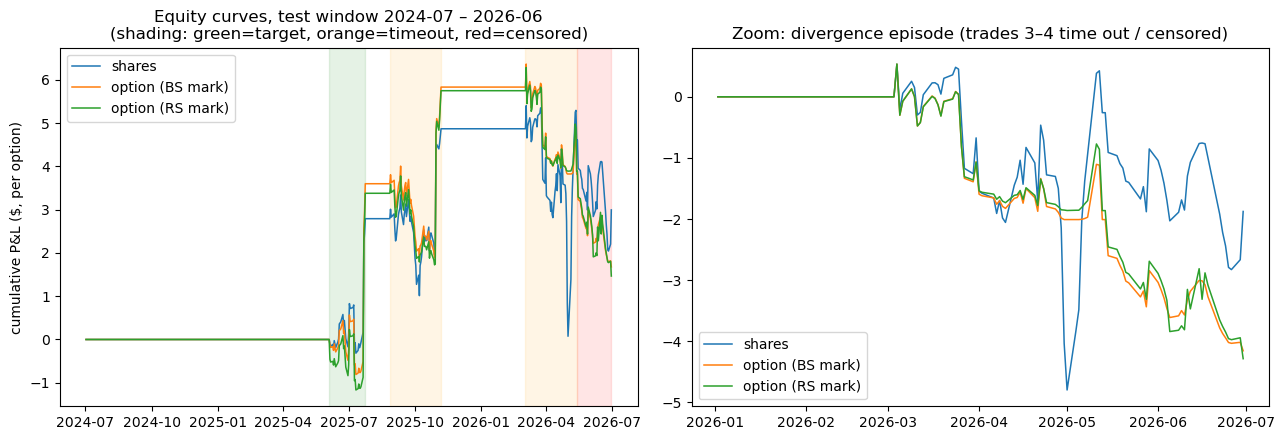

,total_pnl,sharpe,n_trades,mean_trade,std_trade,hit_rate,worst_trade,max_drawdown
shares,2.9950,0.3468,4.0,0.7488,2.0454,0.5,-1.6156,-5.3284
option_BS,1.6793,0.2177,4.0,0.4198,2.9375,0.5,-2.1463,-4.6874
option_RS,1.4664,0.1799,4.0,0.3666,2.9347,0.5,-2.4228,-4.8197


In [9]:
# Markers and the three backtests
bs_marker = BSMarker(SIGMA1, SIGMA2, RHO, r_f, M=100_000, seed=31)
rs_marker = RSMarker(rp, r_f, T_max_steps=MAX_HOLD + 1, seed=32)

pt_bs, dly_bs, deltas_e, prem_bs = backtest_option_pairs(
    prices_test, trades, bs_marker, T_OPT, BETA)
pt_rs, dly_rs, _, prem_rs = backtest_option_pairs(
    prices_test, trades, rs_marker, T_OPT, BETA, regimes=regimes_te)
pt_sh, dly_sh = backtest_share_pairs(prices_test, trades, BETA, deltas_e)

print("entry deltas (FD on marker):",
      {k: round(v, 3) for k, v in deltas_e.items()})
print("entry premiums (BS mark):   ",
      {k: round(v, 3) for k, v in prem_bs.items()})

perf = performance_table(
    {"shares": dly_sh, "option_BS": dly_bs, "option_RS": dly_rs},
    {"shares": pt_sh, "option_BS": pt_bs, "option_RS": pt_rs})

# loss-cap check: a long option can lose at most its premium
worst_allowed = -max(prem_bs.values())
print(f"\noption loss cap: worst possible per-trade loss = -premium "
      f"(<= {worst_allowed:.2f} here); compare 'worst_trade' rows")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for name, d in [("shares", dly_sh), ("option (BS mark)", dly_bs),
                ("option (RS mark)", dly_rs)]:
    ax1.plot(d.cumsum(), label=name, lw=1.1)
for _, tr in trades.iterrows():
    ax1.axvspan(tr.entry_date, tr.exit_date, alpha=0.10,
                color={"target": "green", "timeout": "orange",
                       "end_of_data": "red"}[tr.exit_reason])
ax1.legend()
ax1.set_title("Equity curves, test window 2024-07 – 2026-06\n"
              "(shading: green=target, orange=timeout, red=censored)")
ax1.set_ylabel("cumulative P&L ($, per option)")

# zoom: the out-of-sample divergence episode (trades 3–4)
zoom = slice("2026-01-01", None)
for name, d in [("shares", dly_sh), ("option (BS mark)", dly_bs),
                ("option (RS mark)", dly_rs)]:
    ax2.plot(d.loc[zoom].cumsum(), label=name, lw=1.1)
ax2.legend()
ax2.set_title("Zoom: divergence episode (trades 3–4 time out / censored)")
plt.tight_layout()
plt.show()

perf


- **The signal's out-of-sample record is the real story.** Trade 1 hit
  target ($z: -2.04 \to 0.09$). Trade 2 timed out
  partway back ($2.08 \to 0.56$). Trades 3–4 are the failure mode: the
  spread kept diverging ($2.04 \to 2.20$ timeout; $2.13 \to 3.10$
  **censored**). Consistent with notebook 01's diagnostics (test-window EG
  $p = 0.63$, spread mean $+0.74\sigma$ above the frozen $\theta$): the
  cointegration weakened out of sample, and the backtest shows what each
  vehicle does when that happens.
- **Shares vs options through divergence:** the share book's worst trade is
  $-1.62$ and loses roughly linearly as the spread rises; the option's worst
  trade ($-2.15$ BS, $-2.42$ RS) is **capped at its premium**
  ($1.76$–$2.15$ at entry). That risk cap is the economic argument for the
  option vehicle; it costs time value on the winners (total P&L $3.00$
  shares vs $1.68$/$1.47$ options).
- **BS mark vs RS mark:** identical positions and realized payoffs — the
  rows differ only in daily marks and the model value at trade 1's early
  exit. The gap ($1.68$ vs $1.47$ total, $\approx 0.05$ per trade) is
  *valuation model risk*, consistent with notebook 04's $\sim 2\%$ near-ATM
  gap — not a strategy difference. Do not rank them.
- **Statistical honesty:** $n = 4$ trades, one censored. Sharpe is computed
  on daily P&L that is zero between trades and is not comparable to
  conventional Sharpes. Report, but conclude nothing inferential.

# 7. Conclusions & limitations

**Pair selection and signal (notebook 01).** Screening ~55 pairs on training
data only (2021-01 → 2024-07) with a predetermined rule, MO/PM was selected
(EG $p = 0.015$, half-life $\approx 25$ days, $\hat\beta = 0.735$) with a
strong structural link (2008 split of the same parent). $\hat\beta$ ranged
$0.66$–$0.86$ and the half-life $12$–$29$ days across training sub-windows —
moderate stability, and the frozen-parameter design carries that risk. Out of
sample the relationship weakened (EG $p = 0.63$ on the test window; spread
mean $+0.74\sigma$ above the frozen $\theta$), which the backtest reflects:
one clean mean-reversion win, one partial, two adverse timeouts (one
censored).

**Pricing and variance reduction (notebook 02).** The $K = 0$ exchange
option's Margrabe closed form is an effective control variate for the
no-closed-form $K \neq 0$ option: exact at $K = 0$, roughly **[FILL]$\times$
variance reduction at the traded ATM strike** ($\operatorname{corr}(P, C)
\approx$ [FILL]), decaying as $K$ rises. The reduction is capped by geometry:
for this pair $K_{\text{ATM}} = (1-\beta)S_1(0)$ sits $\sim 3.4$
spread-sigmas above $0$, so the control is nearly a forward — it captures
delta-like variation, not convexity.

**Delta hedging (notebook 03).** Hedging the traded ATM option at
$\{$none, weekly, daily$\}$ reproduces the discrete-hedging
$\sqrt{\Delta t}$ law (weekly/daily std ratio $\approx$ [FILL] vs
$\sqrt 5 \approx 2.24$). FD deltas are essential at this strike: the true
entry deltas are $\approx (\pm 0.5)$ while the Margrabe $K=0$ deltas are
pinned at $(\pm 1)$.

**Regime switching (notebook 04).** Training-window estimation finds
volatilities roughly [FILL] higher in the volatile regime with correlation
[FILL: similar / lower]. Pricing model risk grows with strike (from
$\approx 0$ at $K = 0$ to [FILL]% of price at ATM and beyond) — a
vol-mixture convexity effect. The hedging race is a **measured negative
result**: the detected-regime hedger is indistinguishable from the naive
constant-parameter hedger because the volatile regime's expected duration
([FILL] days) is comparable to the 21-day detection window — the detector
recognizes regimes roughly one regime-lifetime late. Regime information
matters for pricing and risk measurement more than for delta hedging.

**Shares vs options as the vehicle (notebook 05).** Same signal, same entry
sizing: through mean reversion the two vehicles are similar (options lag by
time-value decay); through divergence the option's loss is capped at the
premium while the share loss is unbounded. The BS-marked and RS-marked
option books are the same trade under two valuation models; their gap
([FILL]$ per trade) is model risk, not alpha.

**Honest limitations.**
- Pair selection ran ~55 tests at the 5% level ($\approx 2.9$ expected false
  discoveries); the predetermined rule, controls, economic-link requirement,
  and train-only selection mitigate but do not eliminate this.
- Four trades, one censored: no statistical inference is possible; the
  backtest demonstrates mechanics, not expected profitability.
- Spread options are model-marked, not market-marked; early exits realize
  model value. Realistic for OTC books, but the central caveat.
- Dividends omitted (MO $\approx 9.8\%$, PM $\approx 5.5\%$ trailing yields
  at the training cutoff): over $T \approx 0.2$y this shifts the forward
  spread by $\approx 0.15$ spread-sigmas and deltas by $\approx 2\%$.
- No transaction costs or bid-ask; i.i.d. Monte Carlo only; regime detection
  uses a threshold rule rather than filtered probabilities (HMM/EM is the
  natural extension); European exercise; flat rates; frozen parameters
  (a production system would refit on a rolling window).

**Extensions.** Cointegration-consistent option pricing (Duan & Pliska 2004);
a convexity-matched control variate (Kirk approximation or geometric-average
spread option); filtered regime probabilities (Hamilton 1989 / EM); rolling
re-estimation.

**References.** Margrabe (1978), *The Value of an Option to Exchange One
Asset for Another*, J. Finance; Glasserman (2003), *Monte Carlo Methods in
Financial Engineering* (control variates); Hamilton (1989), *A New Approach
to the Economic Analysis of Nonstationary Time Series*, Econometrica; Duan &
Pliska (2004), *Option Valuation with Co-integrated Asset Prices*, J. Econ.
Dyn. Control; course notebooks 2–12.

**NOTE on AI use:** AI assistance was used for code review, debugging, simplifying the notebook structure, and revising explanatory text. All modeling choices, empirical analysis, interpretation of results, and final project decisions were reviewed and completed by the author.
